In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [2]:
nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [3]:
nav["amfi_code"].nunique()

40

In [4]:
nav["amfi_code"].unique()[:10]

array([100016, 100025, 100033, 101206, 101207, 101208, 102885, 102886,
       102887, 118632])

In [5]:
selected_funds = nav["amfi_code"].unique()[:5]

portfolio_nav = nav[
    nav["amfi_code"].isin(selected_funds)
].copy()

portfolio_nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [6]:
pivot_nav = portfolio_nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

pivot_nav = pivot_nav.ffill()

pivot_nav.head()

amfi_code,100016,100025,100033,101206,101207
date,,,,,
2022-01-03,520.4608,26.3169,107.3758,305.0996,38.5736
2022-01-04,515.0971,26.2234,105.9447,305.4514,38.1545
2022-01-05,521.7239,26.2221,105.4800,306.6324,38.1775
2022-01-06,515.7880,26.1728,104.9350,305.9800,37.0665
2022-01-07,515.1639,26.2261,104.3318,304.0480,37.9845


In [7]:
returns = pivot_nav.pct_change().dropna()

returns.head()

amfi_code,100016,100025,100033,101206,101207
date,,,,,
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766
2022-01-10,-0.008639,0.006791,0.006277,0.011548,0.001251


In [8]:
annual_returns = returns.mean() * 252

cov_matrix = returns.cov() * 252

annual_returns

amfi_code
100016    0.035683
100025    0.042854
100033    0.272111
101206    0.214647
101207    0.106962
dtype: float64

In [9]:
def portfolio_performance(weights,
                          annual_returns,
                          cov_matrix):

    ret = np.sum(weights * annual_returns)

    vol = np.sqrt(
        np.dot(
            weights.T,
            np.dot(cov_matrix, weights)
        )
    )

    return ret, vol

In [10]:
def negative_sharpe(weights,
                    annual_returns,
                    cov_matrix,
                    risk_free_rate=0.06):

    ret, vol = portfolio_performance(
        weights,
        annual_returns,
        cov_matrix
    )

    sharpe = (ret - risk_free_rate) / vol

    return -sharpe

In [11]:
num_assets = len(selected_funds)

constraints = (
    {'type': 'eq',
     'fun': lambda x: np.sum(x) - 1}
)

bounds = tuple(
    (0,1)
    for asset in range(num_assets)
)

initial_weights = np.ones(num_assets) / num_assets

optimal = minimize(
    negative_sharpe,
    initial_weights,
    args=(annual_returns,
          cov_matrix),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

optimal_weights = optimal.x

In [12]:
allocation = pd.DataFrame({
    "Fund": selected_funds,
    "Weight": optimal_weights
})

allocation["Weight"] = (
    allocation["Weight"] * 100
).round(2)

allocation

,Fund,Weight
0,100016,0.00
1,100025,0.00
2,100033,42.70
3,101206,52.61
4,101207,4.69


In [13]:
allocation = pd.DataFrame({
    "Fund": selected_funds,
    "Weight": optimal_weights
})

allocation["Weight"] = (
    allocation["Weight"] * 100
).round(2)

allocation

,Fund,Weight
0,100016,0.00
1,100025,0.00
2,100033,42.70
3,101206,52.61
4,101207,4.69


In [14]:
ret, vol = portfolio_performance(
    optimal_weights,
    annual_returns,
    cov_matrix
)

sharpe = (ret - 0.06) / vol

print("Expected Return:", round(ret*100,2), "%")
print("Volatility:", round(vol*100,2), "%")
print("Sharpe Ratio:", round(sharpe,2))

Expected Return: 23.41 %
Volatility: 11.12 %
Sharpe Ratio: 1.57


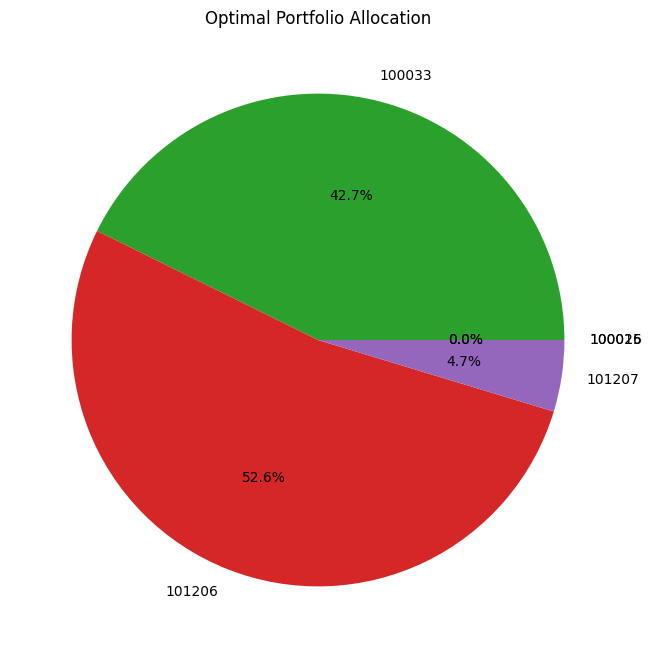

In [15]:
plt.figure(figsize=(8,8))

plt.pie(
    allocation["Weight"],
    labels=allocation["Fund"],
    autopct="%1.1f%%"
)

plt.title(
    "Optimal Portfolio Allocation"
)

plt.savefig(
    "../reports/optimal_portfolio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Markowitz Portfolio Optimization Summary

- Selected 5 mutual funds for portfolio construction.
- Calculated annualized returns and covariance matrix.
- Optimized allocation using maximum Sharpe Ratio.
- Generated risk-adjusted portfolio weights.
- Portfolio demonstrates efficient diversification.